# Facebook: Food pages

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

In [8]:

G = nx.read_edgelist(
    r"C:\Users\carlo\OneDrive\Documents\Latentspacemodels_Networks\Complement\Examples\FBPagesFood\fb-pages-food.edges",
    delimiter=",",nodetype=int,create_using=nx.Graph())

print("Before removing self-loops")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G))

# Remove self-loops
G.remove_edges_from(nx.selfloop_edges(G))
print("\nAfter removing self-loops")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G))

# Largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()

print("\nLargest connected component")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Before removing self-loops
Nodes: 620
Edges: 2102
Self-loops: 11

After removing self-loops
Nodes: 620
Edges: 2091
Self-loops: 0

Largest connected component
Nodes: 620
Edges: 2091


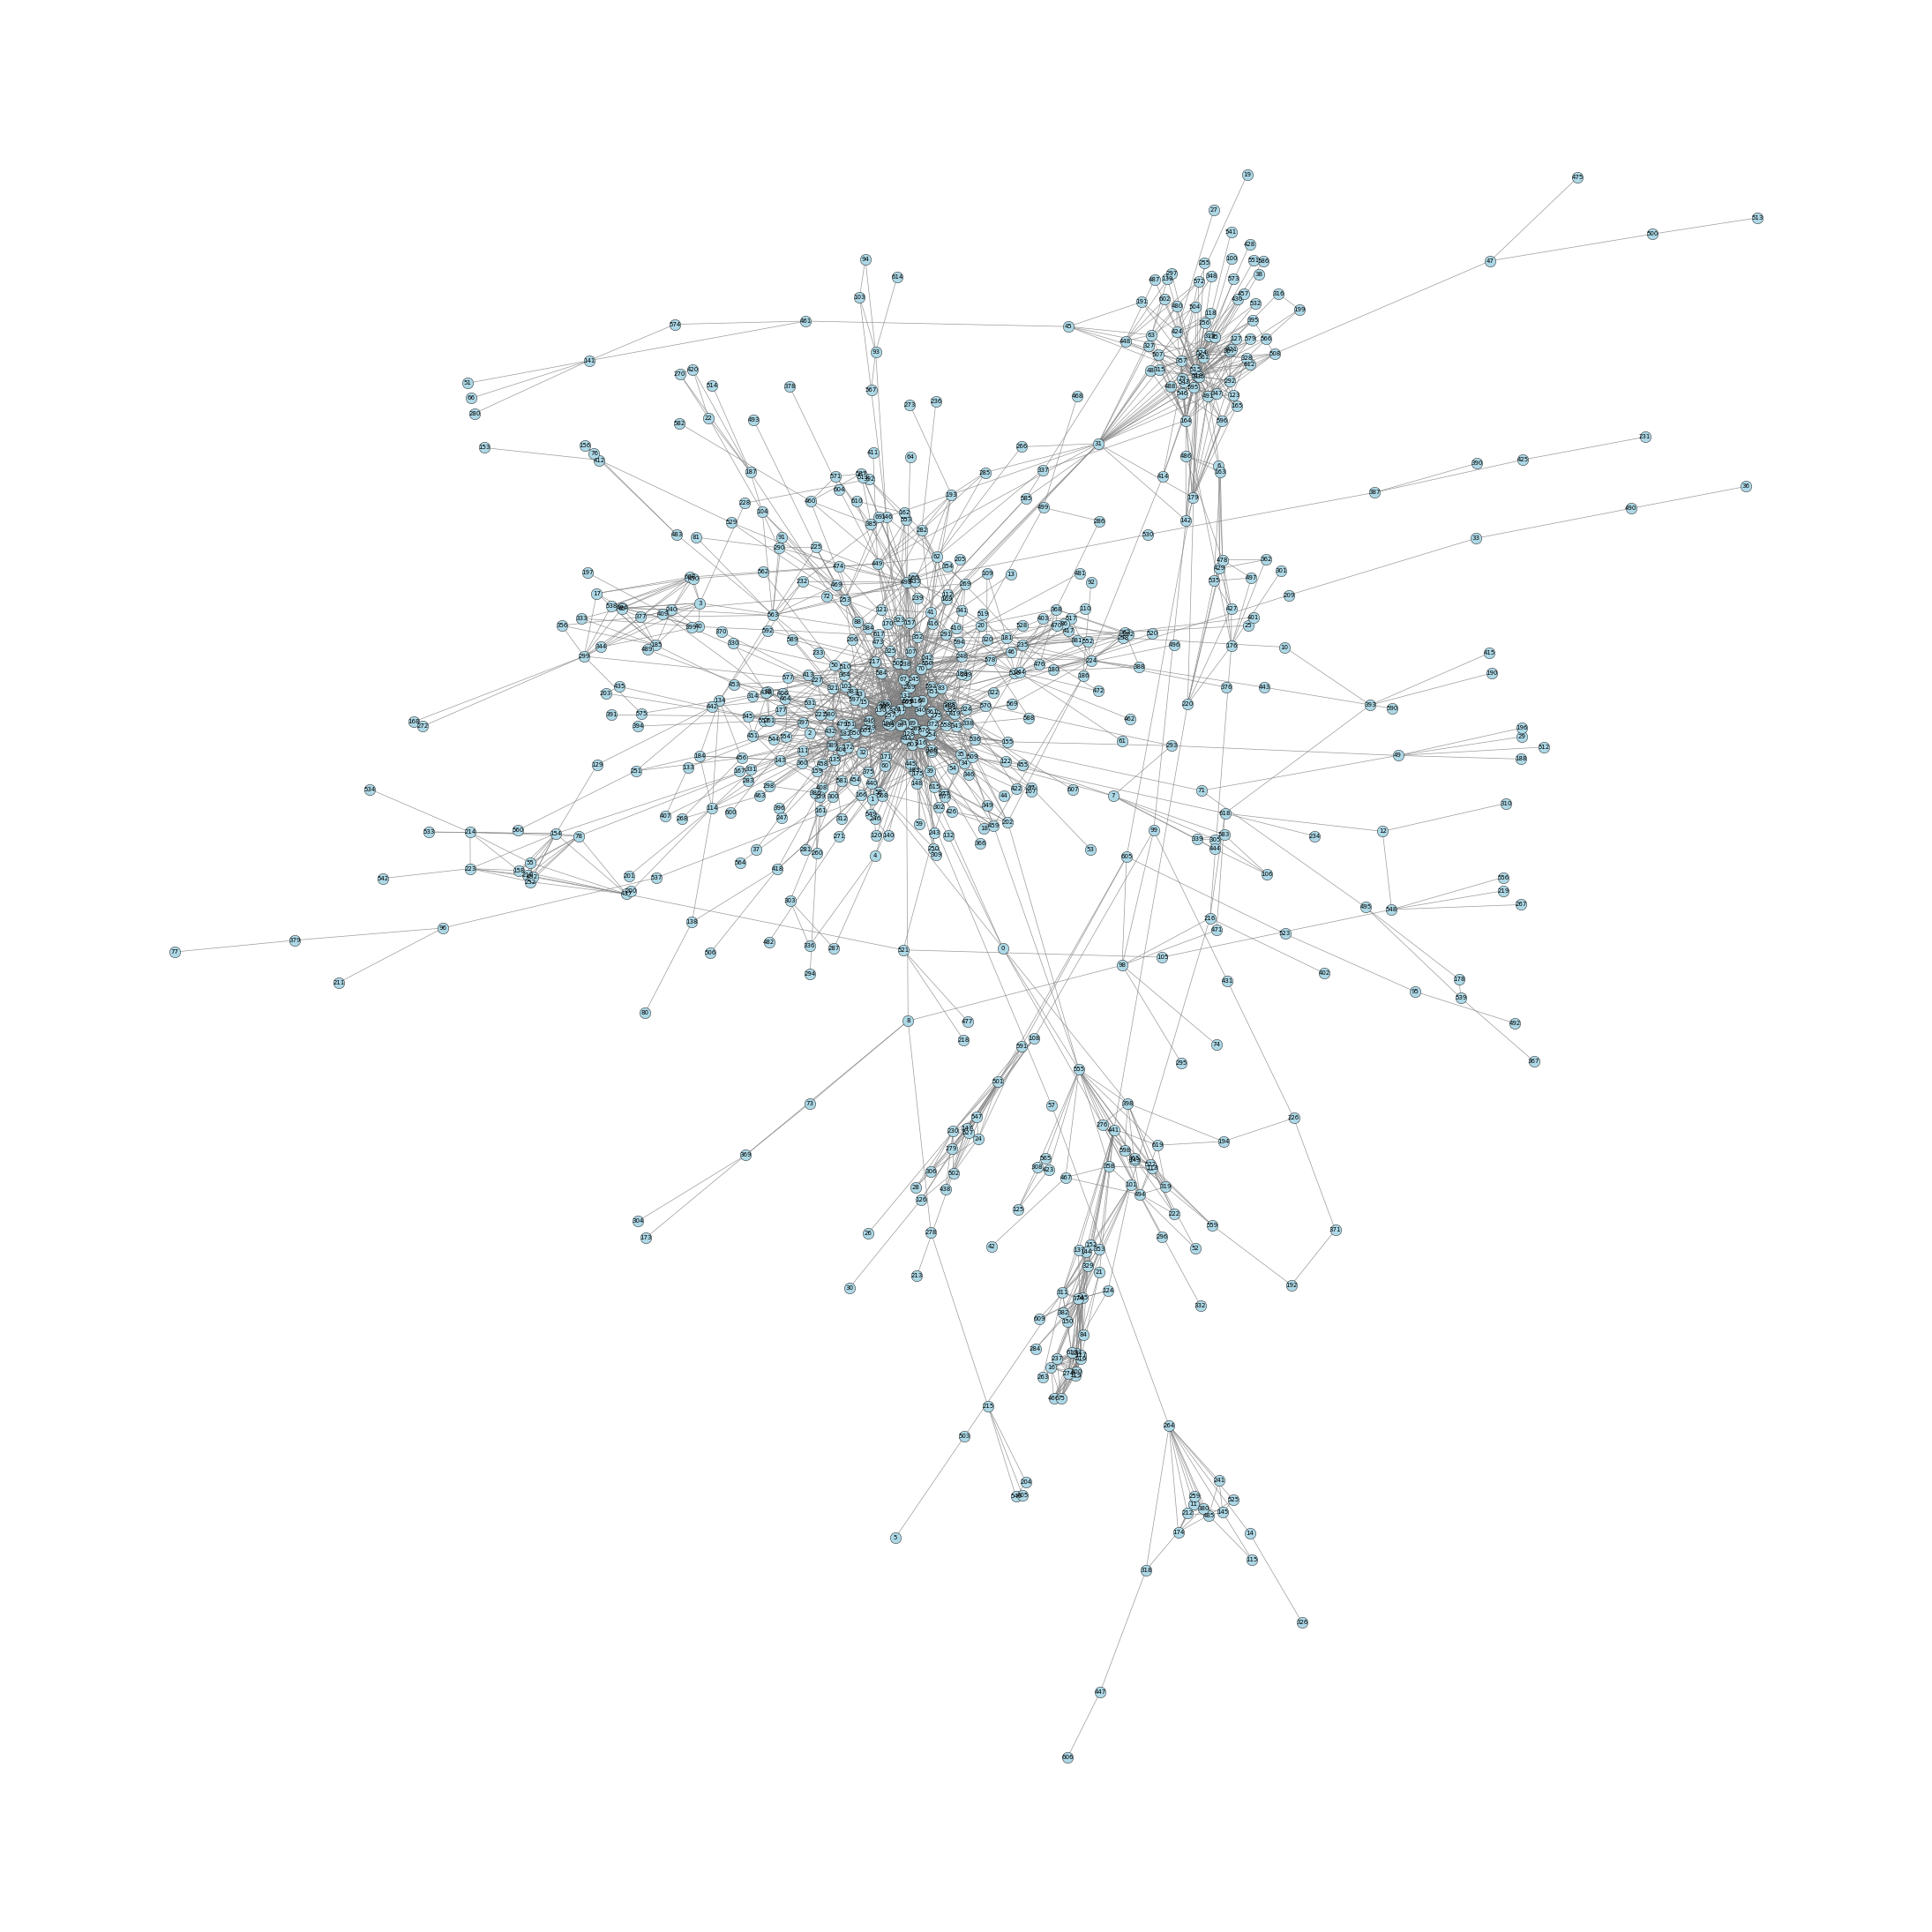

In [13]:

pos = nx.spring_layout(G,seed=42,k=0.8)
plt.figure(figsize=(22,22))
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.80, width=0.5)
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", linewidths=0.3, node_size=80)
nx.draw_networkx_labels(G, pos, font_size=5, font_color="black", font_family="sans-serif")
plt.axis("off")
plt.tight_layout()
plt.show()

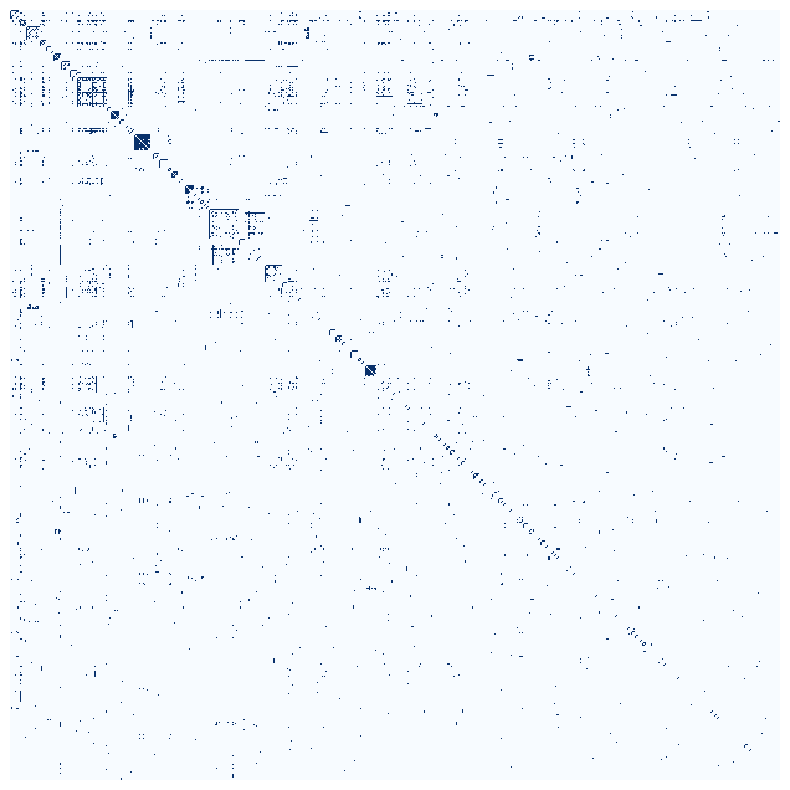

In [14]:

Y = nx.to_numpy_array(G, dtype=int)
plt.figure(figsize=(8,8))
sns.heatmap(Y, cmap="Blues", cbar=False, square=True, xticklabels=False, yticklabels=False, linewidths=0)
plt.tight_layout()
plt.show()

In [ ]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R1_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

In [ ]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R2_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

In [ ]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R3_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
with open("FBPagesFood_R2_c.pkl", "rb") as f:
    results_R2_c = pickle.load(f)
Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R2_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [ ]:
with open("FBPagesFood_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [ ]:
with open("FBPagesFood_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [ ]:
with open("FBPagesFood_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

In [ ]:
geometry = HyperbolicGeometry(d=2, D=10.0)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("FBPagesFood_H2_p.pkl")

## Results

### Laplacian spectrum

### Summary metrics